# Load Data


In [11]:
import pandas as pd

df = pd.read_excel("../data/Superstore-final.xlsx")

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [12]:
import os
os.makedirs("../output/basic_analysis", exist_ok=True)

In [13]:
import os

print("Current Directory:")
print(os.getcwd())

Current Directory:
D:\Desktop\Superstore Sales Analytics Dashboard\python


# Dataset Information & Missing values

In [14]:
print(df.shape)

print(df.info())

print(df.describe())

(9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 n

In [15]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


# Sales & Profit KPIs

In [16]:
total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_orders = df['Order ID'].nunique()

print(total_sales)
print(total_profit)
print(total_orders)

2297200.8603
286397.0217
5009


# Region Analysis

In [17]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


# Category Analysis

In [18]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


# Top 10 Selling Products

In [19]:
top_products = df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


# Monthly Sales Trend

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

In [21]:
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

# Visualization
## Monthly Sales Trend

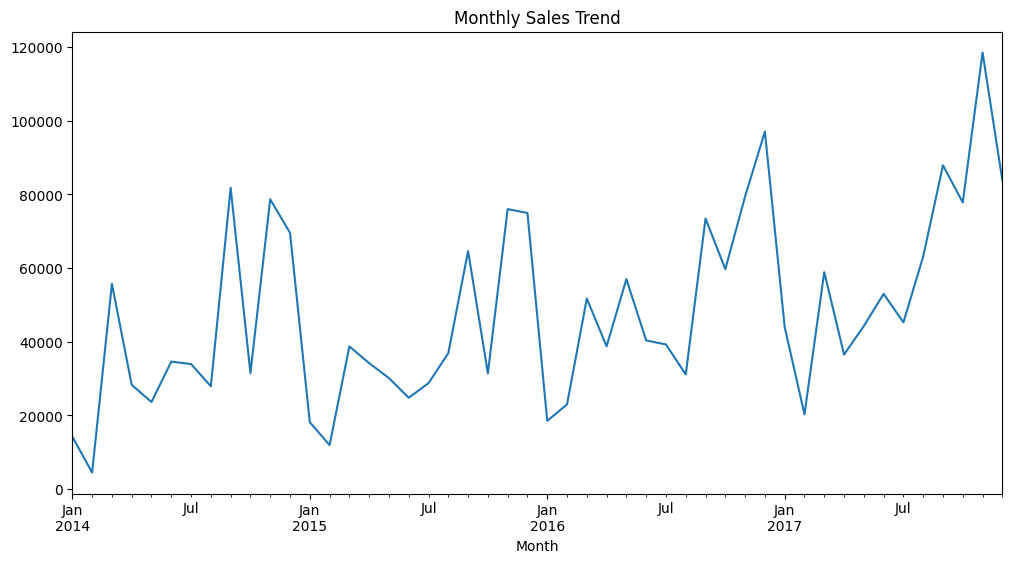

In [23]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    figsize=(12,6)
)

plt.title("Monthly Sales Trend")
plt.savefig(
    "../output/basic_analysis/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sales by Region

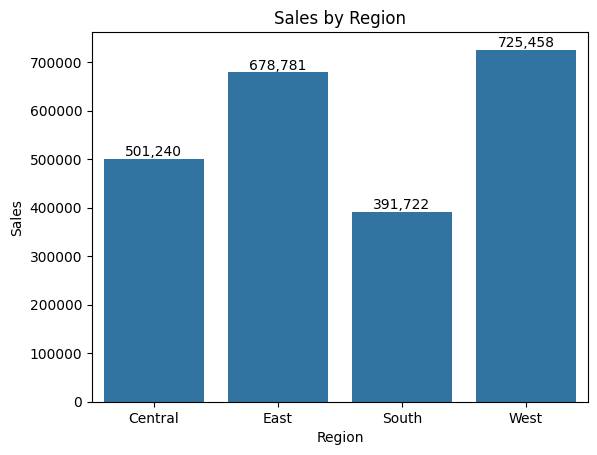

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

# Add exact values on bars
for i, value in enumerate(region_sales.values):
    ax.text(
        i,                  # x position
        value,              # y position
        f'{value:,.0f}',    # format with commas
        ha='center',
        va='bottom'
    )

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.savefig(
    "../output/basic_analysis/Sales by Region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Profit by Category

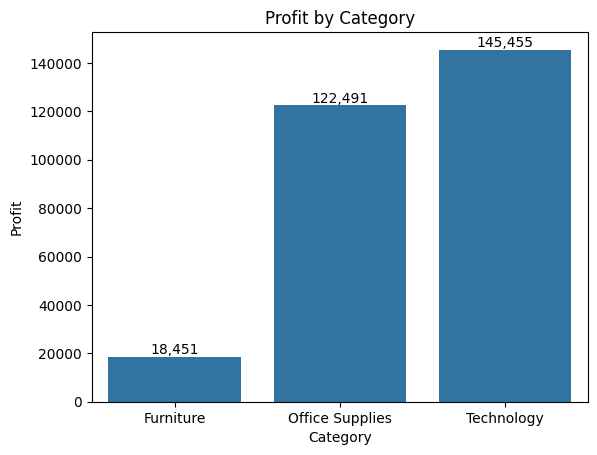

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

# Add exact values
for i, value in enumerate(category_profit.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.xlabel("Category")
plt.savefig(
    "../output/basic_analysis/Profit by Category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()